# RAG System Corpus Analysis

This notebook analyzes the extracted entities from the Knowledge Graph (Neo4j).

**Sections:**
1. **Data Loading & Parsing** — Load entities from export.csv
2. **Entity Overview** — Distribution and statistics
3. **Confidence Score Analysis** — Quality assessment
4. **Paper Coverage** — Entities per paper, ArXiv categories
5. **Visualizations** — Charts and insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading & Parsing

Load and parse the Neo4j entity exports (CONCEPT, PERSON, DOCUMENT entities).

In [ ]:
def parse_neo4j_export(filepath, allowed_root=None):
    """Parse Neo4j entities from export CSV.

    `filepath` is resolved and required to live under `allowed_root` (default:
    the notebook's parent directory) to mitigate path traversal — see issue #343.
    """
    from pathlib import Path as _Path
    resolved = _Path(filepath).expanduser().resolve()
    root = _Path(allowed_root).expanduser().resolve() if allowed_root else _Path.cwd().resolve()
    try:
        resolved.relative_to(root)
    except ValueError as exc:
        raise ValueError(f"Refusing to read {resolved!s}: outside allowed root {root!s}") from exc

    entities = []

    with open(resolved, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    for line in lines[1:]:  # Skip header
        if not line.strip() or ':Entity' not in line:
            continue
        
        try:
            entity = {}
            
            # Detect entity type
            if ':CONCEPT:' in line:
                entity['label'] = 'CONCEPT'
            elif ':PERSON' in line:
                entity['label'] = 'PERSON'
            else:
                entity['label'] = 'OTHER'
            
            # Extract name
            name_match = re.search(r'name:\s*""([^"]+)""', line)
            entity['name'] = name_match.group(1) if name_match else 'Unknown'
            
            # Extract confidence_score
            conf_match = re.search(r'confidence_score:\s*([\d.]+)', line)
            entity['confidence_score'] = float(conf_match.group(1)) if conf_match else 0.0
            
            # Extract paper_id from metadata
            paper_match = re.search(r"'paper_id':\s*'([^']+)'", line)
            entity['paper_id'] = paper_match.group(1) if paper_match else 'Unknown'
            
            # Extract arxiv_category from metadata
            cat_match = re.search(r"'arxiv_category':\s*'([^']+)'", line)
            entity['arxiv_category'] = cat_match.group(1) if cat_match else 'Unknown'
            
            # Extract entity_type_original
            type_match = re.search(r"'entity_type_original':\s*'([^']+)'", line)
            entity['entity_type'] = type_match.group(1) if type_match else 'Unknown'
            
            # Extract extraction_method
            method_match = re.search(r'extraction_method:\s*""([^"]+)""', line)
            entity['extraction_method'] = method_match.group(1) if method_match else 'Unknown'
            
            entities.append(entity)
        except (re.error, IndexError, KeyError, ValueError, AttributeError):
            # Skip individual malformed rows but surface unexpected errors.
            continue
    
    return pd.DataFrame(entities)

# Load data
df = parse_neo4j_export('../datasets/export.csv')
print(f"Total Entities Loaded: {len(df)}")
df.head(10)

## 2. Entity Overview

Key statistics about the extracted entities.

In [3]:
# Overview statistics
print("=" * 50)
print("CORPUS OVERVIEW")
print("=" * 50)
print(f"Total Entities: {len(df)}")
print(f"Unique Papers: {df['paper_id'].nunique()}")
print(f"Unique ArXiv Categories: {df['arxiv_category'].nunique()}")
print(f"\nEntity Labels: {df['label'].value_counts().to_dict()}")
print(f"Entity Types: {df['entity_type'].value_counts().to_dict()}")
print(f"Extraction Methods: {df['extraction_method'].value_counts().to_dict()}")
print("=" * 50)

# Average entities per paper
n_papers = df['paper_id'].nunique()
avg_entities = len(df) / n_papers if n_papers > 0 else 0
print(f"Average Entities per Paper: {avg_entities:.1f}")

CORPUS OVERVIEW
Total Entities: 25
Unique Papers: 5
Unique ArXiv Categories: 4

Entity Labels: {'OTHER': 13, 'PERSON': 12}
Entity Types: {'author': 12, 'model': 7, 'dataset': 3, 'other': 2, 'metric': 1}
Extraction Methods: {'rule_based': 12, 'llm_extraction': 12, 'pattern_matching': 1}
Average Entities per Paper: 5.0


## 3. Confidence Score Analysis

Analyze the quality of extracted entities via confidence scores.

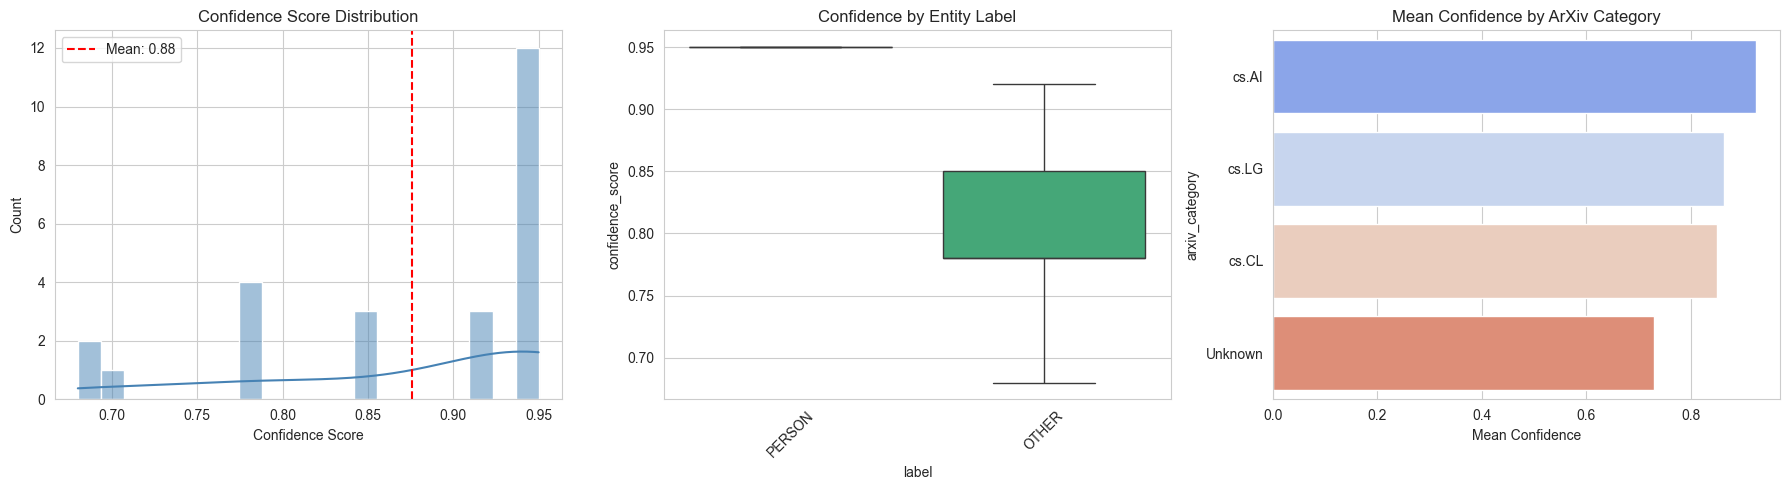


Confidence Score Statistics:
count    25.000000
mean      0.875600
std       0.095354
min       0.680000
25%       0.780000
50%       0.920000
75%       0.950000
max       0.950000
Name: confidence_score, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confidence Score Distribution
sns.histplot(df['confidence_score'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['confidence_score'].mean(), color='red', linestyle='--', 
                label=f"Mean: {df['confidence_score'].mean():.2f}")
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Confidence by Entity Label
if df['label'].nunique() > 1:
    sns.boxplot(data=df, x='label', y='confidence_score', ax=axes[1], palette='viridis')
else:
    sns.boxplot(data=df, y='confidence_score', ax=axes[1], color='steelblue')
axes[1].set_title('Confidence by Entity Label')
axes[1].tick_params(axis='x', rotation=45)

# 3. Confidence by ArXiv Category
cat_conf = df.groupby('arxiv_category')['confidence_score'].mean().sort_values(ascending=False)
sns.barplot(x=cat_conf.values, y=cat_conf.index, ax=axes[2], palette='coolwarm')
axes[2].set_title('Mean Confidence by ArXiv Category')
axes[2].set_xlabel('Mean Confidence')

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print("\nConfidence Score Statistics:")
print(df['confidence_score'].describe())

## 4. Paper Coverage Analysis

How many entities are extracted per paper? ArXiv category breakdown.

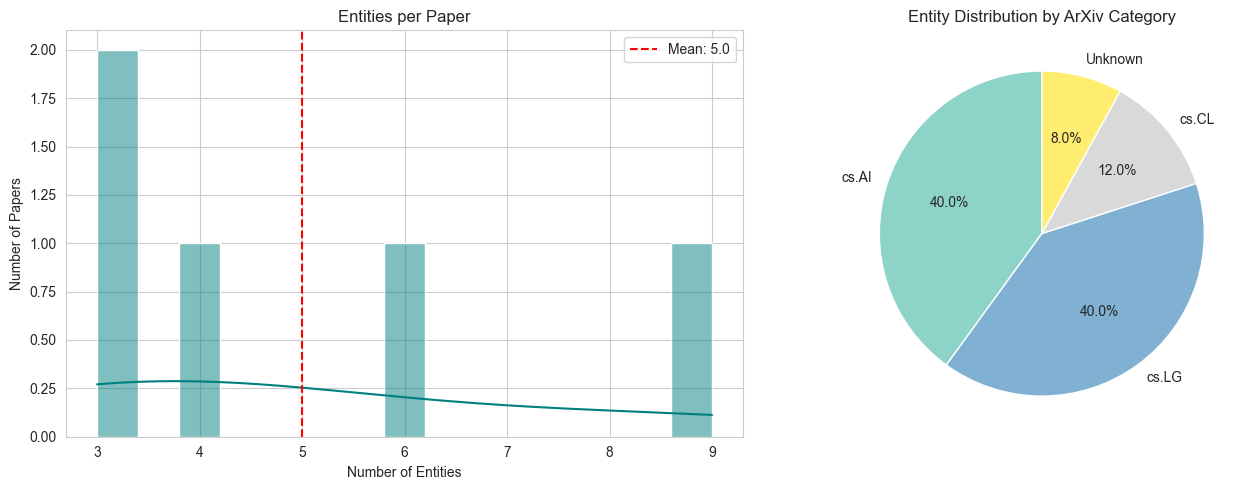


Paper Coverage Summary:
       entity_count
count       5.00000
mean        5.00000
std         2.54951
min         3.00000
25%         3.00000
50%         4.00000
75%         6.00000
max         9.00000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Entities per Paper
entities_per_paper = df.groupby('paper_id').size().reset_index(name='entity_count')
sns.histplot(entities_per_paper['entity_count'], bins=15, ax=axes[0], color='teal', kde=True)
axes[0].axvline(entities_per_paper['entity_count'].mean(), color='red', linestyle='--', 
                label=f"Mean: {entities_per_paper['entity_count'].mean():.1f}")
axes[0].set_title('Entities per Paper')
axes[0].set_xlabel('Number of Entities')
axes[0].set_ylabel('Number of Papers')
axes[0].legend()

# 2. Entities by ArXiv Category
cat_counts = df['arxiv_category'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Entity Distribution by ArXiv Category')

plt.tight_layout()
plt.savefig('paper_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Paper coverage table
print("\nPaper Coverage Summary:")
print(entities_per_paper.describe())

## 5. Entity Breakdown by Type

Breakdown of entities by label and extraction method.

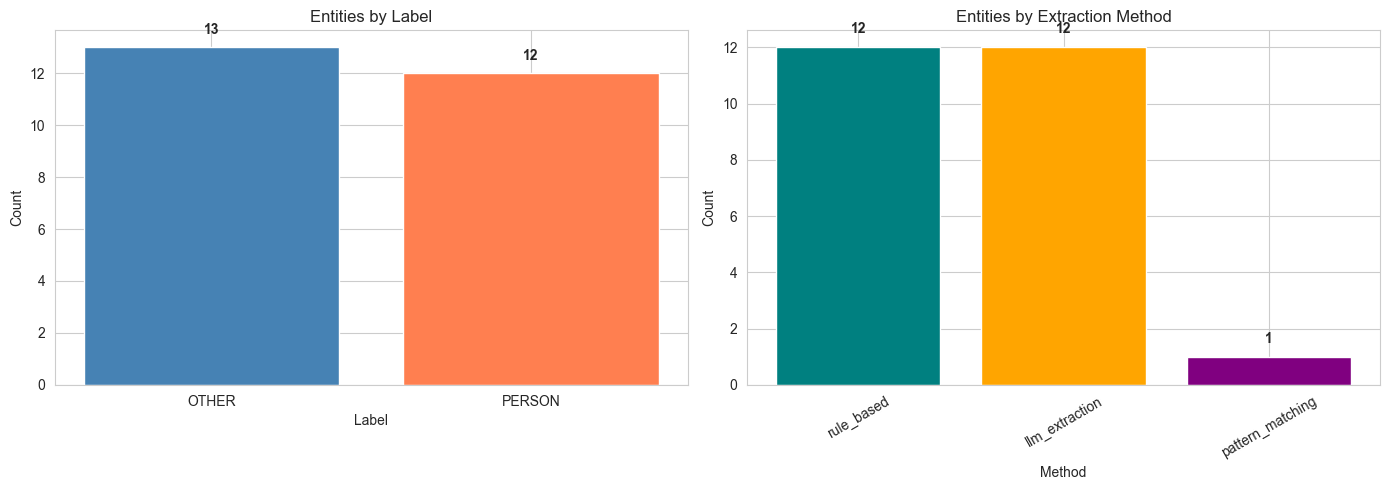

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Entity Labels
label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['steelblue', 'coral', 'green'][:len(label_counts)])
axes[0].set_title('Entities by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 2. Extraction Methods
method_counts = df['extraction_method'].value_counts()
axes[1].bar(method_counts.index, method_counts.values, color=['teal', 'orange', 'purple'][:len(method_counts)])
axes[1].set_title('Entities by Extraction Method')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(method_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('entity_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Quality Assessment Summary

Overall extraction quality metrics.

In [7]:
# Quality thresholds
high_conf = (df['confidence_score'] >= 0.85).sum()
med_conf = ((df['confidence_score'] >= 0.7) & (df['confidence_score'] < 0.85)).sum()
low_conf = (df['confidence_score'] < 0.7).sum()

print("=" * 50)
print("EXTRACTION QUALITY SUMMARY")
print("=" * 50)
print(f"High Confidence (≥0.85): {high_conf} ({100*high_conf/len(df):.1f}%)")
print(f"Medium Confidence (0.7-0.85): {med_conf} ({100*med_conf/len(df):.1f}%)")
print(f"Low Confidence (<0.7): {low_conf} ({100*low_conf/len(df):.1f}%)")
print("=" * 50)
print(f"\nOverall Quality Score: {df['confidence_score'].mean():.2f}")

EXTRACTION QUALITY SUMMARY
High Confidence (≥0.85): 18 (72.0%)
Medium Confidence (0.7-0.85): 5 (20.0%)
Low Confidence (<0.7): 2 (8.0%)

Overall Quality Score: 0.88
